## About
relatively well performing but poor scoreing so it has to be tweaked but could be nice to show in work
 

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))
from anomaly_detection.utils.plotting_styles import apply_global_style

In [4]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [6]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [7]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [8]:
pt = dataset[34]

# to get the actual lenght
pt_len = len(pt)
print(type(pt))
pt = torch.tensor(pt.reshape(1, 1, pt_len))
encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=3),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

print(f"The encoded data shape: {encoder(pt).shape}")

<class 'numpy.ndarray'>
The encoded data shape: torch.Size([1, 1, 24])


In [9]:
encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=5, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.Sigmoid(),
            )
        
decoder = nn.Sequential(
            nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.ConvTranspose1d(1, 1, kernel_size=4, stride=2),  
            nn.BatchNorm1d(1),
            nn.Sigmoid(),
            )
print(encoder(pt).shape)
decoder(encoder(pt)).shape

torch.Size([1, 1, 23])


torch.Size([1, 1, 96])

In [10]:
class AE_old(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
                nn.Conv1d(1, 1, kernel_size=5, stride=2),  
                nn.BatchNorm1d(1),
                nn.ReLU(),
                
                nn.Conv1d(1, 1, kernel_size=4, stride=2, padding=1),  
                nn.BatchNorm1d(1),
                nn.Sigmoid(),
                )
        
        self.decoder = nn.Sequential(
                nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2),  
                nn.BatchNorm1d(1),
                nn.ReLU(),
                
                nn.ConvTranspose1d(1, 1, kernel_size=4, stride=2),  
                nn.BatchNorm1d(1),
                nn.Sigmoid(),
                )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [11]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = AE_old()
criterion = nn.KLDivLoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.0005)

In [12]:
from anomaly_detection.utils.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=15, dataloader=train_loader, model=ae_conv, val_loader=test_loader, optimizer=optimizer, criterion=criterion)

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\functional.py:3359: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


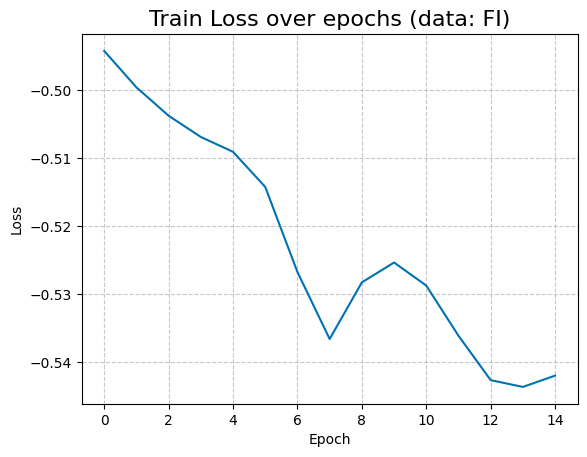

In [13]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

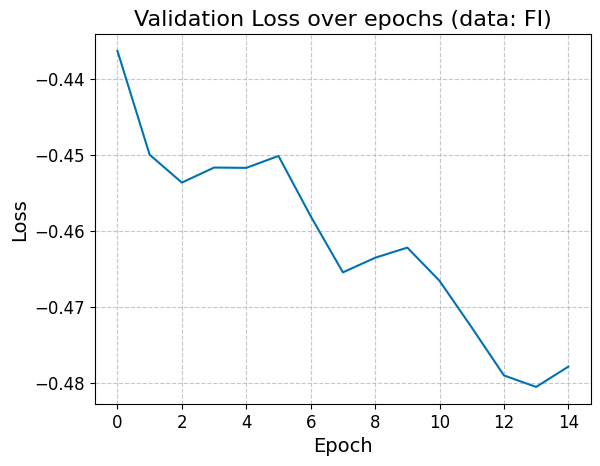

In [14]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [15]:
full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\functional.py:3359: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


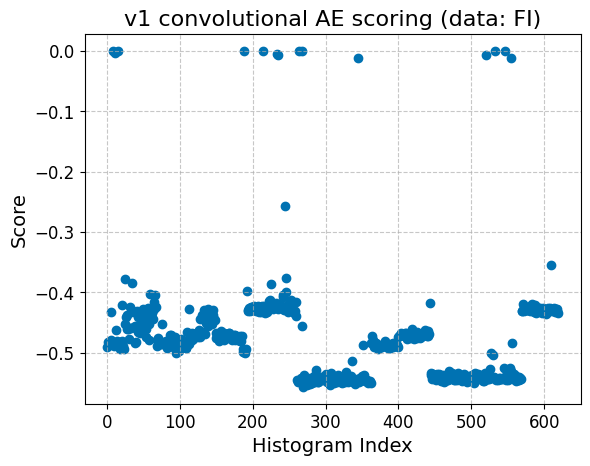

In [17]:
from anomaly_detection.utils.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")
model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pt = pt.reshape(1,1,96)
        pred = ae_conv(pt)
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

#score = eval_and_plot_score(model=ae_conv, dataloader=dataloader, criterion=criterion)
plt.scatter(range(len(score)), score)
plt.show()

In [18]:
outliers = np.where(np.array(score) > -0.07)
outliers

(array([  8,  11,  15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546,
        555]),)

In [19]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.reshape(1,1,96)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


tensor(0.0869)


c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


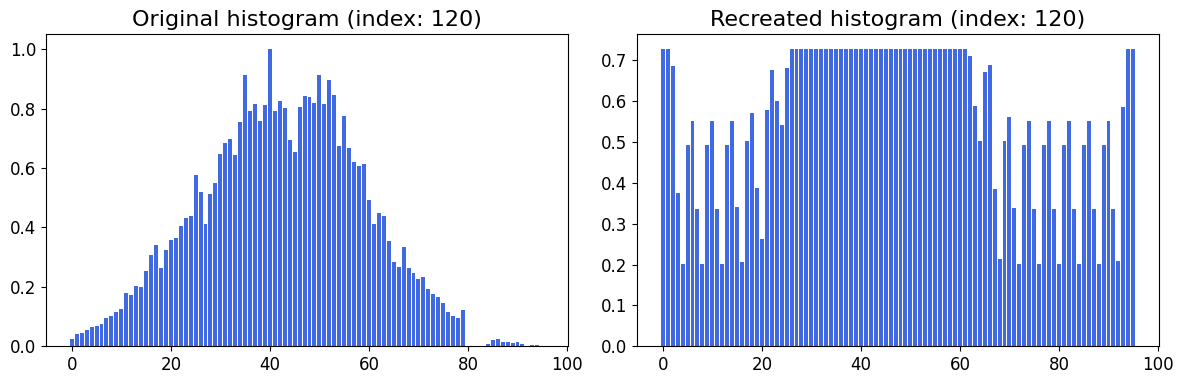

In [20]:
idx = 120

ae_conv.eval()
pred = ae_conv(full_dataset[idx].reshape(1, 1, 96)).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
print(loss)
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)

plt.tight_layout()
plt.show()

In [21]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [8, 15, 188, 214, 263, 268, 533, 546, 11, 233]
lowest scores [306, 274, 269]


In [22]:
#torch.save(ae, 'functional_ae_conv_2.pth')

In [23]:
(dataset[0] == dataset[0]).all()

np.True_

In [24]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(dataset):
        data = data.unsqueeze(0)     
        pred = ae(data).numpy()
         
        for p in preds:
            if (pred == p).all():
                break
        else:
            preds.append(pred)
        
        if idx % 100 == 0: 
            print(idx)

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'